# Lab 15 — The Transformer Architecture

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-15-transformers.ipynb)

This lab accompanies **Chapter 15: The Transformer Architecture** in *Mathematics of Natural Language Processing*.

The goal is not to train a large language model. The goal is to understand the mathematical architecture well enough to debug real implementations.

In this lab, you will build a small Transformer block from scratch using NumPy. You will see how the architecture combines:

1. token embeddings and positional information;
2. scaled dot-product attention;
3. multi-head attention;
4. residual connections;
5. layer normalization;
6. position-wise feedforward networks;
7. causal masking;
8. vocabulary logits and cross-entropy.

Repository for the book: [https://github.com/wanghemath/Book-MathNLP](https://github.com/wanghemath/Book-MathNLP).

## 1. Mathematical background

A token sequence of length $T$ is represented by a matrix

$$
X \in R^{T \times d},
$$

where row $x_i$ is the vector representation of token position $i$ and $d$ is the model dimension.

A Transformer block is a map

$$
F: R^{T \times d} \to R^{T \times d}.
$$

A common encoder block has the form

$$
H = \operatorname{LayerNorm}(X + \operatorname{MHA}(X)),
$$

$$
Y = \operatorname{LayerNorm}(H + \operatorname{FFN}(H)).
$$

The architecture separates two types of mixing:

- **Attention mixes token positions**: each output row can be a weighted combination of value vectors from other positions.
- **The feedforward network mixes feature coordinates**: the same small neural network is applied to each row independently.

The residual connections preserve an identity path, which helps information and gradients flow through many layers.

## 2. Setup

This notebook uses only standard scientific Python packages available in Google Colab.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(2026)

## 3. A tiny token sequence

We start with a toy vocabulary and a short sentence. Real systems use much larger vocabularies and learned subword tokenizers, but the matrix shapes are the same.

In [2]:
tokens = ["<bos>", "the", "model", "learns", "language", "."]
vocab = {tok: i for i, tok in enumerate(tokens)}
id_to_token = {i: tok for tok, i in vocab.items()}

sentence = ["<bos>", "the", "model", "learns", "language", "."]
ids = np.array([vocab[t] for t in sentence])

print("tokens:", sentence)
print("ids:", ids)
print("sequence length T =", len(ids))
print("vocabulary size |V| =", len(vocab))

tokens: ['<bos>', 'the', 'model', 'learns', 'language', '.']
ids: [0 1 2 3 4 5]
sequence length T = 6
vocabulary size |V| = 6


## 4. Token embeddings and positional information

An embedding matrix has shape

$$
E \in R^{|V| \times d}.
$$

Looking up the rows indexed by the token ids gives

$$
X_{\text{tok}} \in R^{T \times d}.
$$

Self-attention without positional information is permutation equivariant: if we reorder the input rows, the output rows reorder in the same way. Therefore we need position vectors.

In [3]:
T = len(ids)
d = 8
V = len(vocab)

E = rng.normal(scale=0.4, size=(V, d))
X_tok = E[ids]

print("Embedding matrix E shape:", E.shape)
print("Token representation X_tok shape:", X_tok.shape)
print("First token vector:")
print(X_tok[0])

Embedding matrix E shape: (6, 8)
Token representation X_tok shape: (6, 8)
First token vector:
[-0.3172  0.0962 -0.7585  0.5583  0.2553 -0.1168 -0.1248  0.1215]


### Sinusoidal positional encoding

One classical choice is sinusoidal positional encoding. For position $p$ and coordinate $j$,

$$
\operatorname{PE}(p,2j) = \sin\left(p / 10000^{2j/d}\right),
$$

$$
\operatorname{PE}(p,2j+1) = \cos\left(p / 10000^{2j/d}\right).
$$

The Transformer input is

$$
X = X_{\text{tok}} + P.
$$

In [4]:
def sinusoidal_positional_encoding(T, d):
    P = np.zeros((T, d))
    positions = np.arange(T)[:, None]
    div_terms = np.exp(np.arange(0, d, 2) * (-np.log(10000.0) / d))
    P[:, 0::2] = np.sin(positions * div_terms)
    if d > 1:
        P[:, 1::2] = np.cos(positions * div_terms[:P[:, 1::2].shape[1]])
    return P

P = sinusoidal_positional_encoding(T, d)
X = X_tok + P

print("Position matrix P shape:", P.shape)
print("Transformer input X shape:", X.shape)
print(pd.DataFrame(P, columns=[f"coord_{j}" for j in range(d)]))

Position matrix P shape: (6, 8)
Transformer input X shape: (6, 8)
    coord_0   coord_1   coord_2   coord_3   coord_4  coord_5  coord_6   coord_7
0  0.000000  1.000000  0.000000  1.000000  0.000000  1.00000    0.000  1.000000
1  0.841471  0.540302  0.099833  0.995004  0.010000  0.99995    0.001  1.000000
2  0.909297 -0.416147  0.198669  0.980067  0.019999  0.99980    0.002  0.999998
3  0.141120 -0.989992  0.295520  0.955336  0.029996  0.99955    0.003  0.999996
4 -0.756802 -0.653644  0.389418  0.921061  0.039989  0.99920    0.004  0.999992
5 -0.958924  0.283662  0.479426  0.877583  0.049979  0.99875    0.005  0.999988


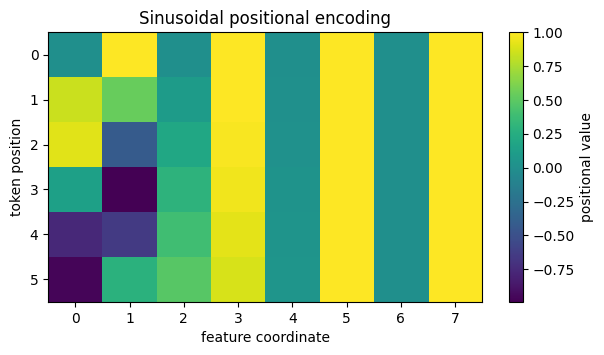

In [5]:
plt.figure(figsize=(7, 3.5))
plt.imshow(P, aspect="auto")
plt.colorbar(label="positional value")
plt.xlabel("feature coordinate")
plt.ylabel("token position")
plt.title("Sinusoidal positional encoding")
plt.show()

## 5. Stable row-wise softmax

Attention uses a row-wise softmax. For a score matrix $S \in R^{T \times T}$,

$$
A_{ij} = \frac{\exp(S_{ij})}{\sum_{k=1}^T \exp(S_{ik})}.
$$

Each row of $A$ is a probability distribution over key positions.

For numerical stability, subtract the maximum in each row before exponentiating.

In [6]:
def softmax_rows(S):
    S = np.asarray(S, dtype=float)
    S_shift = S - S.max(axis=1, keepdims=True)
    E_exp = np.exp(S_shift)
    return E_exp / E_exp.sum(axis=1, keepdims=True)

S_demo = np.array([[1.0, 2.0, 3.0], [1000.0, 1001.0, 1002.0]])
A_demo = softmax_rows(S_demo)
print(A_demo)
print("row sums:", A_demo.sum(axis=1))

[[0.09   0.2447 0.6652]
 [0.09   0.2447 0.6652]]
row sums: [1. 1.]


## 6. One attention head

For one head, the model forms

$$
Q=XW_Q, \qquad K=XW_K, \qquad V=XW_V,
$$

where $Q,K,V \in R^{T \times d_h}$.

The scaled dot-product attention matrix is

$$
A = \operatorname{softmax}_{\text{row}}\left(\frac{QK^T + M}{\sqrt{d_h}}\right),
$$

and the head output is

$$
Z = AV.
$$

The mask $M$ is optional. Padding masks and causal masks are represented by adding very negative values to forbidden positions.

In [7]:
def attention_head(X, WQ, WK, WV, mask=None):
    Q = X @ WQ
    K = X @ WK
    Vv = X @ WV
    scores = (Q @ K.T) / math.sqrt(Q.shape[1])
    if mask is not None:
        scores = scores + mask
    A = softmax_rows(scores)
    Z = A @ Vv
    cache = {"Q": Q, "K": K, "V": Vv, "scores": scores, "A": A}
    return Z, cache

head_dim = 4
WQ = rng.normal(scale=0.3, size=(d, head_dim))
WK = rng.normal(scale=0.3, size=(d, head_dim))
WV = rng.normal(scale=0.3, size=(d, head_dim))

Z_one, cache_one = attention_head(X, WQ, WK, WV)
print("Q shape:", cache_one["Q"].shape)
print("K shape:", cache_one["K"].shape)
print("V shape:", cache_one["V"].shape)
print("attention matrix A shape:", cache_one["A"].shape)
print("head output Z shape:", Z_one.shape)
print("row sums of A:", cache_one["A"].sum(axis=1))

Q shape: (6, 4)
K shape: (6, 4)
V shape: (6, 4)
attention matrix A shape: (6, 6)
head output Z shape: (6, 4)
row sums of A: [1. 1. 1. 1. 1. 1.]


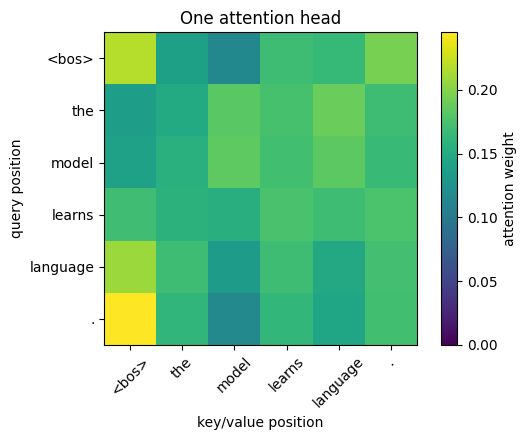

In [8]:
plt.figure(figsize=(6, 4.5))
plt.imshow(cache_one["A"], vmin=0, vmax=cache_one["A"].max())
plt.colorbar(label="attention weight")
plt.xticks(range(T), sentence, rotation=45)
plt.yticks(range(T), sentence)
plt.xlabel("key/value position")
plt.ylabel("query position")
plt.title("One attention head")
plt.tight_layout()
plt.show()

### Reflection

Look at one row of the attention matrix. That row answers:

> For this query token, how much weight is assigned to each key/value token?

Attention weights are useful diagnostics, but they are not automatically causal explanations of model behavior.

## 7. Multi-head attention

A Transformer block uses several attention heads in parallel. If there are $h$ heads and model dimension $d$, a common choice is

$$
d_h = d / h.
$$

Each head produces a matrix in $R^{T \times d_h}$. The head outputs are concatenated into a matrix in $R^{T \times d}$ and projected back to $R^{T \times d}$.

In [9]:
def multi_head_attention(X, params, mask=None, return_cache=True):
    WQ, WK, WV, WO = params["WQ"], params["WK"], params["WV"], params["WO"]
    h = WQ.shape[0]
    head_outputs = []
    caches = []
    for r in range(h):
        Z_r, cache_r = attention_head(X, WQ[r], WK[r], WV[r], mask=mask)
        head_outputs.append(Z_r)
        caches.append(cache_r)
    Z_cat = np.concatenate(head_outputs, axis=1)
    Y = Z_cat @ WO
    if return_cache:
        return Y, {"head_outputs": head_outputs, "caches": caches, "Z_cat": Z_cat}
    return Y

h = 2
assert d % h == 0, "d must be divisible by the number of heads."
dh = d // h

mha_params = {
    "WQ": rng.normal(scale=0.25, size=(h, d, dh)),
    "WK": rng.normal(scale=0.25, size=(h, d, dh)),
    "WV": rng.normal(scale=0.25, size=(h, d, dh)),
    "WO": rng.normal(scale=0.25, size=(h * dh, d)),
}

MHA_X, mha_cache = multi_head_attention(X, mha_params)

print("Number of heads h:", h)
print("Head dimension dh:", dh)
print("Concatenated head output shape:", mha_cache["Z_cat"].shape)
print("Multi-head output shape:", MHA_X.shape)

Number of heads h: 2
Head dimension dh: 4
Concatenated head output shape: (6, 8)
Multi-head output shape: (6, 8)


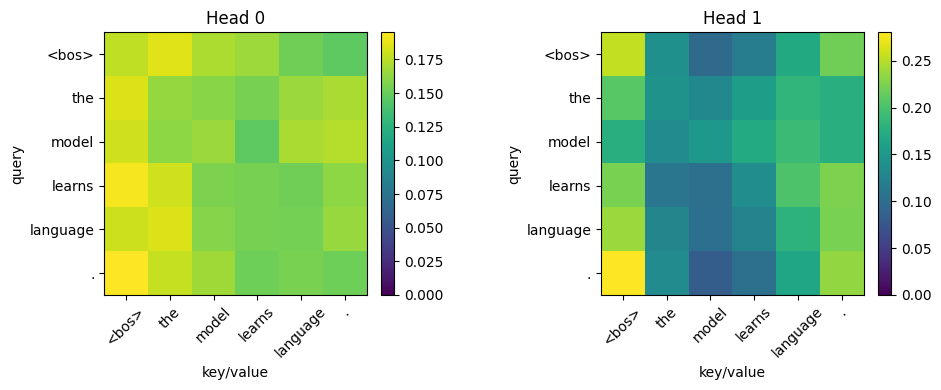

In [10]:
fig, axes = plt.subplots(1, h, figsize=(5*h, 4))
if h == 1:
    axes = [axes]
for r, ax in enumerate(axes):
    A = mha_cache["caches"][r]["A"]
    im = ax.imshow(A, vmin=0, vmax=A.max())
    ax.set_title(f"Head {r}")
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(sentence, rotation=45)
    ax.set_yticklabels(sentence)
    ax.set_xlabel("key/value")
    ax.set_ylabel("query")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Residual connections

A residual sublayer computes

$$
R(X)=X+G(X).
$$

If $G$ is hard to optimize, the identity path still allows information to pass through. In scalar form,

$$
R'(x)=1+G'(x).
$$

This identity term is one reason deep residual networks are easier to train than plain deep compositions.

In [11]:
H_residual = X + MHA_X
print("X shape:", X.shape)
print("MHA(X) shape:", MHA_X.shape)
print("X + MHA(X) shape:", H_residual.shape)
print("First row before residual:", X[0])
print("First row after residual addition:", H_residual[0])

X shape: (6, 8)
MHA(X) shape: (6, 8)
X + MHA(X) shape: (6, 8)
First row before residual: [-0.3172  1.0962 -0.7585  1.5583  0.2553  0.8832 -0.1248  1.1215]
First row after residual addition: [ 0.5185  0.8816 -0.8258  1.1561  0.0217  0.8151 -0.0435  1.3711]


## 9. Layer normalization

Layer normalization standardizes each token row across feature coordinates:

$$
\operatorname{LN}(x)_j = \gamma_j \frac{x_j - \mu(x)}{\sqrt{\sigma^2(x)+\epsilon}} + \beta_j.
$$

For this educational implementation, start with $\gamma=1$ and $\beta=0$.

In [12]:
def layer_norm(X, gamma=None, beta=None, eps=1e-5):
    X = np.asarray(X, dtype=float)
    mu = X.mean(axis=1, keepdims=True)
    var = ((X - mu) ** 2).mean(axis=1, keepdims=True)
    Z = (X - mu) / np.sqrt(var + eps)
    if gamma is None:
        gamma = np.ones(X.shape[1])
    if beta is None:
        beta = np.zeros(X.shape[1])
    return Z * gamma + beta

H_norm = layer_norm(H_residual)
print("row means after layer norm:", H_norm.mean(axis=1))
print("row variances after layer norm:", H_norm.var(axis=1))

row means after layer norm: [ 0. -0. -0. -0.  0. -0.]
row variances after layer norm: [1. 1. 1. 1. 1. 1.]


## 10. Position-wise feedforward network

After attention mixes rows, the feedforward network transforms each row independently:

$$
\operatorname{FFN}(h_i)=\sigma(h_i W_1+b_1)W_2+b_2.
$$

In matrix form,

$$
\operatorname{FFN}(H)=\sigma(HW_1 + b_1)W_2 + b_2.
$$

The same weights are used at every token position.

In [13]:
def relu(U):
    return np.maximum(U, 0.0)

def ffn(H, params):
    return relu(H @ params["W1"] + params["b1"]) @ params["W2"] + params["b2"]

dff = 4 * d
ffn_params = {
    "W1": rng.normal(scale=0.25, size=(d, dff)),
    "b1": np.zeros(dff),
    "W2": rng.normal(scale=0.25, size=(dff, d)),
    "b2": np.zeros(d),
}

FFN_H = ffn(H_norm, ffn_params)
print("H_norm shape:", H_norm.shape)
print("Hidden FFN dimension dff:", dff)
print("FFN(H) shape:", FFN_H.shape)

H_norm shape: (6, 8)
Hidden FFN dimension dff: 32
FFN(H) shape: (6, 8)


## 11. A full Transformer encoder block

Now combine the pieces:

$$
H = \operatorname{LN}(X + \operatorname{MHA}(X)),
$$

$$
Y = \operatorname{LN}(H + \operatorname{FFN}(H)).
$$

This is a **post-norm** educational block. Many modern large models use pre-norm variants, but the components are the same.

In [14]:
def transformer_encoder_block(X, params, mask=None):
    attn_out, attn_cache = multi_head_attention(X, params, mask=mask)
    H = layer_norm(X + attn_out, gamma=params.get("ln1_gamma"), beta=params.get("ln1_beta"))
    ffn_out = ffn(H, params)
    Y = layer_norm(H + ffn_out, gamma=params.get("ln2_gamma"), beta=params.get("ln2_beta"))
    return Y, {"attn_out": attn_out, "H": H, "ffn_out": ffn_out, "attn_cache": attn_cache}

block_params = {}
block_params.update(mha_params)
block_params.update(ffn_params)
block_params["ln1_gamma"] = np.ones(d)
block_params["ln1_beta"] = np.zeros(d)
block_params["ln2_gamma"] = np.ones(d)
block_params["ln2_beta"] = np.zeros(d)

Y_enc, block_cache = transformer_encoder_block(X, block_params)
print("Input X shape:", X.shape)
print("Output Y_enc shape:", Y_enc.shape)
print("First token before block:")
print(X[0])
print("First token after block:")
print(Y_enc[0])

Input X shape: (6, 8)
Output Y_enc shape: (6, 8)
First token before block:
[-0.3172  1.0962 -0.7585  1.5583  0.2553  0.8832 -0.1248  1.1215]
First token after block:
[ 0.413   1.1047 -1.8944  0.0717 -0.432  -0.4267 -0.4105  1.5741]


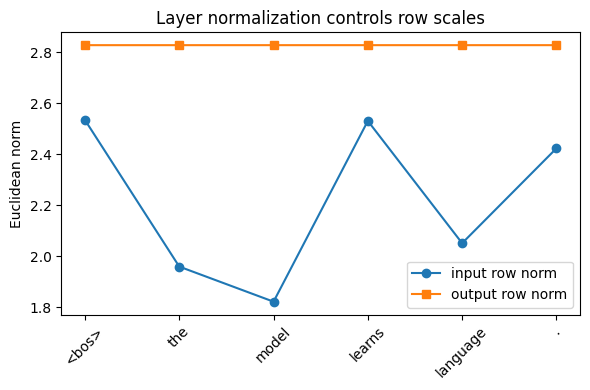

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(np.linalg.norm(X, axis=1), marker="o", label="input row norm")
plt.plot(np.linalg.norm(Y_enc, axis=1), marker="s", label="output row norm")
plt.xticks(range(T), sentence, rotation=45)
plt.ylabel("Euclidean norm")
plt.title("Layer normalization controls row scales")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Encoder self-attention versus decoder causal attention

An encoder can use bidirectional attention: every token can attend to every other token.

A decoder-only language model must prevent position $i$ from looking at future positions $j>i$. This is done with a causal mask:

$$
M_{ij}=\begin{cases}
0, & j \le i,\\
-\infty, & j > i.
\end{cases}
$$

In [16]:
def causal_mask(T, negative_value=-1e9):
    mask = np.triu(np.ones((T, T)), k=1)
    return np.where(mask == 1, negative_value, 0.0)

M_causal = causal_mask(T)
print(M_causal)

[[ 0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00]]


First head causal attention matrix:
[[1.     0.     0.     0.     0.     0.    ]
 [0.5293 0.4707 0.     0.     0.     0.    ]
 [0.3552 0.3186 0.3261 0.     0.     0.    ]
 [0.2812 0.2644 0.2283 0.2262 0.     0.    ]
 [0.2161 0.2216 0.1912 0.1859 0.1852 0.    ]
 [0.1951 0.1776 0.1671 0.1523 0.1557 0.152 ]]
largest future attention weight: 0.0


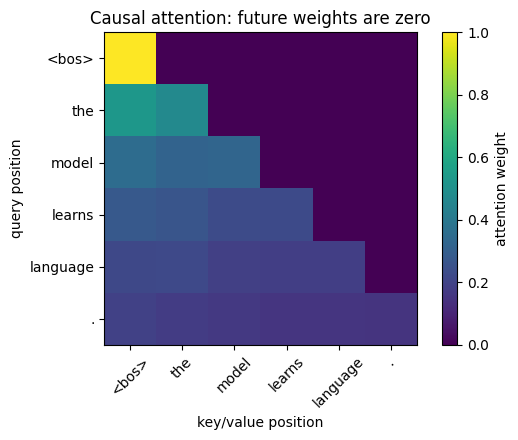

In [17]:
Y_dec, dec_cache = transformer_encoder_block(X, block_params, mask=M_causal)
A_causal = dec_cache["attn_cache"]["caches"][0]["A"]

print("First head causal attention matrix:")
print(A_causal)
print("largest future attention weight:", np.triu(A_causal, k=1).max())

plt.figure(figsize=(6, 4.5))
plt.imshow(A_causal, vmin=0, vmax=A_causal.max())
plt.colorbar(label="attention weight")
plt.xticks(range(T), sentence, rotation=45)
plt.yticks(range(T), sentence)
plt.xlabel("key/value position")
plt.ylabel("query position")
plt.title("Causal attention: future weights are zero")
plt.tight_layout()
plt.show()

## 13. Decoder output logits and cross-entropy

A decoder-only language model maps each hidden state to vocabulary logits:

$$
z_t = h_t W_U + b_U \in R^{|V|}.
$$

After softmax, this gives a probability distribution for the next token.

For the sequence

```text
<bos> the model learns language .
```

position 0 predicts `the`, position 1 predicts `model`, and so on.

In [18]:
WU = rng.normal(scale=0.25, size=(d, V))
bU = np.zeros(V)

logits = Y_dec @ WU + bU
probs = softmax_rows(logits)

target_next = ids[1:]  # next-token labels for positions 0 through T-2
pred_positions = np.arange(T - 1)

nll = -np.log(probs[pred_positions, target_next] + 1e-12)
loss = nll.mean()
perplexity = np.exp(loss)

print("logits shape:", logits.shape)
print("probabilities shape:", probs.shape)
print("next-token targets:", [id_to_token[i] for i in target_next])
print("negative log-likelihood by position:", nll)
print("average cross-entropy loss:", loss)
print("perplexity:", perplexity)

for t in range(T - 1):
    top = int(np.argmax(probs[t]))
    true = target_next[t]
    print(f"position {t}: true next = {id_to_token[true]:>8s}; top prediction = {id_to_token[top]:>8s}; p(true) = {probs[t, true]:.3f}")

logits shape: (6, 6)
probabilities shape: (6, 6)
next-token targets: ['the', 'model', 'learns', 'language', '.']
negative log-likelihood by position: [1.7867 2.1256 2.0986 2.3137 2.1034]
average cross-entropy loss: 2.085590111151033
perplexity: 8.049340085800862
position 0: true next =      the; top prediction =        .; p(true) = 0.168
position 1: true next =    model; top prediction =    <bos>; p(true) = 0.119
position 2: true next =   learns; top prediction =    <bos>; p(true) = 0.123
position 3: true next = language; top prediction =    <bos>; p(true) = 0.099
position 4: true next =        .; top prediction =    <bos>; p(true) = 0.122


### Important note

The parameters above are random. The model has not been trained, so the probabilities are not meaningful yet. The purpose is to understand the shape and the objective.

## 14. Parameter counting

Ignoring biases, multi-head attention has approximately:

- $3d^2$ weights for query, key, value projections;
- $d^2$ weights for the output projection;
- $2d d_{ff}$ weights for the feedforward network;
- $4d$ parameters for two layer normalization modules.

So one block has roughly

$$
4d^2 + 2d d_{ff} + 4d
$$

parameters.

In [19]:
def transformer_block_parameter_count(d, dff, include_bias=False):
    attention = 4 * d * d
    feedforward = 2 * d * dff
    layernorm = 4 * d
    total = attention + feedforward + layernorm
    if include_bias:
        total += 4 * d      # Q, K, V, O biases approximately
        total += dff + d    # FFN biases
    return {
        "attention_weights": attention,
        "feedforward_weights": feedforward,
        "layernorm_parameters": layernorm,
        "total": total,
    }

rows = []
for model_dim in [128, 256, 512, 768]:
    counts = transformer_block_parameter_count(model_dim, 4 * model_dim)
    rows.append({"d": model_dim, "dff": 4 * model_dim, **counts})

pd.DataFrame(rows)

,d,dff,attention_weights,feedforward_weights,layernorm_parameters,total
0,128,512,65536,131072,512,197120
1,256,1024,262144,524288,1024,787456
2,512,2048,1048576,2097152,2048,3147776
3,768,3072,2359296,4718592,3072,7080960


## 15. Complexity: why long context is expensive

Self-attention forms a score matrix

$$
S = QK^T \in R^{T \times T}.
$$

This produces a quadratic dependence on sequence length. If $T$ doubles, the number of pairwise scores grows by a factor of four.

In [20]:
lengths = np.array([64, 128, 256, 512, 1024, 2048, 4096])
scores = lengths ** 2

complexity_df = pd.DataFrame({
    "sequence_length_T": lengths,
    "attention_scores_T_squared": scores,
    "relative_to_T_64": scores / scores[0],
})
complexity_df

,sequence_length_T,attention_scores_T_squared,relative_to_T_64
0,64,4096,1.0
1,128,16384,4.0
2,256,65536,16.0
3,512,262144,64.0
4,1024,1048576,256.0
5,2048,4194304,1024.0
6,4096,16777216,4096.0


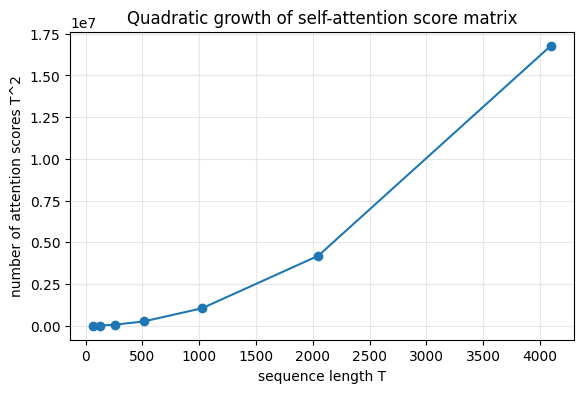

In [21]:
plt.figure(figsize=(6.5, 4))
plt.plot(lengths, scores, marker="o")
plt.xlabel("sequence length T")
plt.ylabel("number of attention scores T^2")
plt.title("Quadratic growth of self-attention score matrix")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Same words, different order

A useful diagnostic is to compare two sequences with the same tokens in different orders. Without positional information, attention treats the input as a set-like object up to permutation. With positional information, order can change the representation.

In [22]:
sentence_a = ["<bos>", "the", "model", "learns", "language", "."]
sentence_b = ["<bos>", "language", "learns", "the", "model", "."]
ids_a = np.array([vocab[t] for t in sentence_a])
ids_b = np.array([vocab[t] for t in sentence_b])

X_a_no_pos = E[ids_a]
X_b_no_pos = E[ids_b]

X_a_pos = X_a_no_pos + P
X_b_pos = X_b_no_pos + P

Y_a_no_pos, _ = transformer_encoder_block(X_a_no_pos, block_params)
Y_b_no_pos, _ = transformer_encoder_block(X_b_no_pos, block_params)
Y_a_pos, _ = transformer_encoder_block(X_a_pos, block_params)
Y_b_pos, _ = transformer_encoder_block(X_b_pos, block_params)

# Compare simple sequence representations by averaging rows.
def sequence_vector(Y):
    return Y.mean(axis=0)

def cosine(u, v):
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))

print("Cosine between mean sequence vectors:")
print("without positional information:", cosine(sequence_vector(Y_a_no_pos), sequence_vector(Y_b_no_pos)))
print("with positional information:   ", cosine(sequence_vector(Y_a_pos), sequence_vector(Y_b_pos)))

Cosine between mean sequence vectors:
without positional information: 0.9999999999994682
with positional information:    0.9939800323059991


The average sequence vector is only one simple summary. Real models often use a special classification token, pooling, or task-specific heads. Still, this experiment shows why positional information matters.

## 17. Exercises

Complete these exercises inside the notebook.

### Exercise 1 — Shape audit

Let $T=10$, $d=12$, $h=3$, and $d_h=4$. Write the shapes of $X$, $W_Q^{(r)}$, $Q_r$, $Q_rK_r^T$, $A_r$, $Z_r$, the concatenated matrix, and the final multi-head output.

### Exercise 2 — Change the number of heads

Modify the code so that $d=12$ and $h=3$. Check every shape. What condition must hold between $d$ and $h$?

### Exercise 3 — Layer normalization by hand

Compute layer normalization for

$$
x=(1,3,5)
$$

with $\gamma=(1,1,1)$, $\beta=(0,0,0)$, and $\epsilon=0$. Then verify using code.

### Exercise 4 — Causal mask

Write the causal mask for $T=5$. Explain why row 2 can attend to columns 0, 1, and 2 but not columns 3 and 4 when Python zero-based indexing is used.

### Exercise 5 — Parameter count

Compute the approximate number of parameters in one block with $d=768$ and $d_{ff}=3072$, ignoring biases.

### Exercise 6 — Encoder or decoder?

For each task, decide whether encoder-only, decoder-only, or encoder-decoder is most natural:

1. sentiment classification;
2. autocomplete;
3. machine translation;
4. named-entity recognition;
5. abstractive summarization.

### Exercise 7 — Interpret attention cautiously

Choose one attention matrix from this lab. Identify the largest weight in each row. Does that automatically explain the model's prediction? Why or why not?

## 18. Mini-project — Build and test a tiny Transformer block

Create a new toy vocabulary and two short sentences. Then build a Transformer block from scratch.

Your project should include:

1. a token-to-id dictionary;
2. an embedding matrix;
3. positional encodings;
4. multi-head self-attention;
5. residual connections;
6. layer normalization;
7. a feedforward network;
8. a causal mask experiment;
9. an output layer for next-token probabilities;
10. a short explanation checking all matrix shapes.

Suggested report questions:

- Which part of the block mixes token positions?
- Which part mixes feature coordinates?
- Why is the causal mask necessary for next-token prediction?
- What happens to the parameter count when $d$ doubles?
- What happens to the attention cost when $T$ doubles?

## 19. AI-assisted learning prompts

Use an AI assistant as a mathematical critic, not just as a code generator.

### Prompt A — Dimension audit

> Check every matrix dimension in my NumPy Transformer block. Identify the shape of each intermediate matrix and explain where shape errors are most likely.

### Prompt B — Masking bug search

> Inspect my attention function for masking and softmax-axis bugs. Explain the mathematical consequence of each bug.

### Prompt C — Architecture comparison

> Explain the mathematical difference between an RNN recurrence and Transformer self-attention. Include the interaction path length and the computational tradeoff.

### Prompt D — Parameter count

> Derive the approximate parameter count of a Transformer block with model dimension d and feedforward dimension dff. Explain why the feedforward network often dominates the block parameter count.

## 20. Summary

In this lab you implemented the essential pieces of a Transformer block:

- token embeddings and positional encodings;
- stable row-wise softmax;
- scaled dot-product attention;
- multi-head attention;
- residual connections;
- layer normalization;
- position-wise feedforward networks;
- causal masking;
- next-token logits, cross-entropy, and perplexity;
- parameter and complexity estimates.

The core mathematical viewpoint is:

$$
\text{Transformer block}: R^{T \times d} \to R^{T \times d}.
$$

Attention mixes rows. Feedforward networks mix columns. Residual connections and layer normalization make the deep composition trainable.